# Experiment 5: Decision Tree and Random Forest - A Comparative Classification Study
Breast cancer classification using Decision Tree and Random Forest with hyperparameter tuning.

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc)

sns.set(style="whitegrid")
%matplotlib inline

## 2. Load Dataset and Encode Labels

In [4]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Exploratory Data Analysis

In [5]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

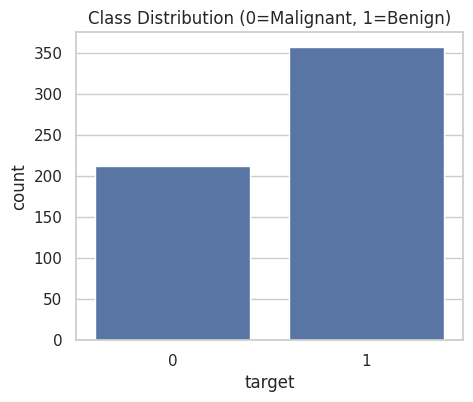

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Class Distribution (0=Malignant, 1=Benign)")
plt.show()

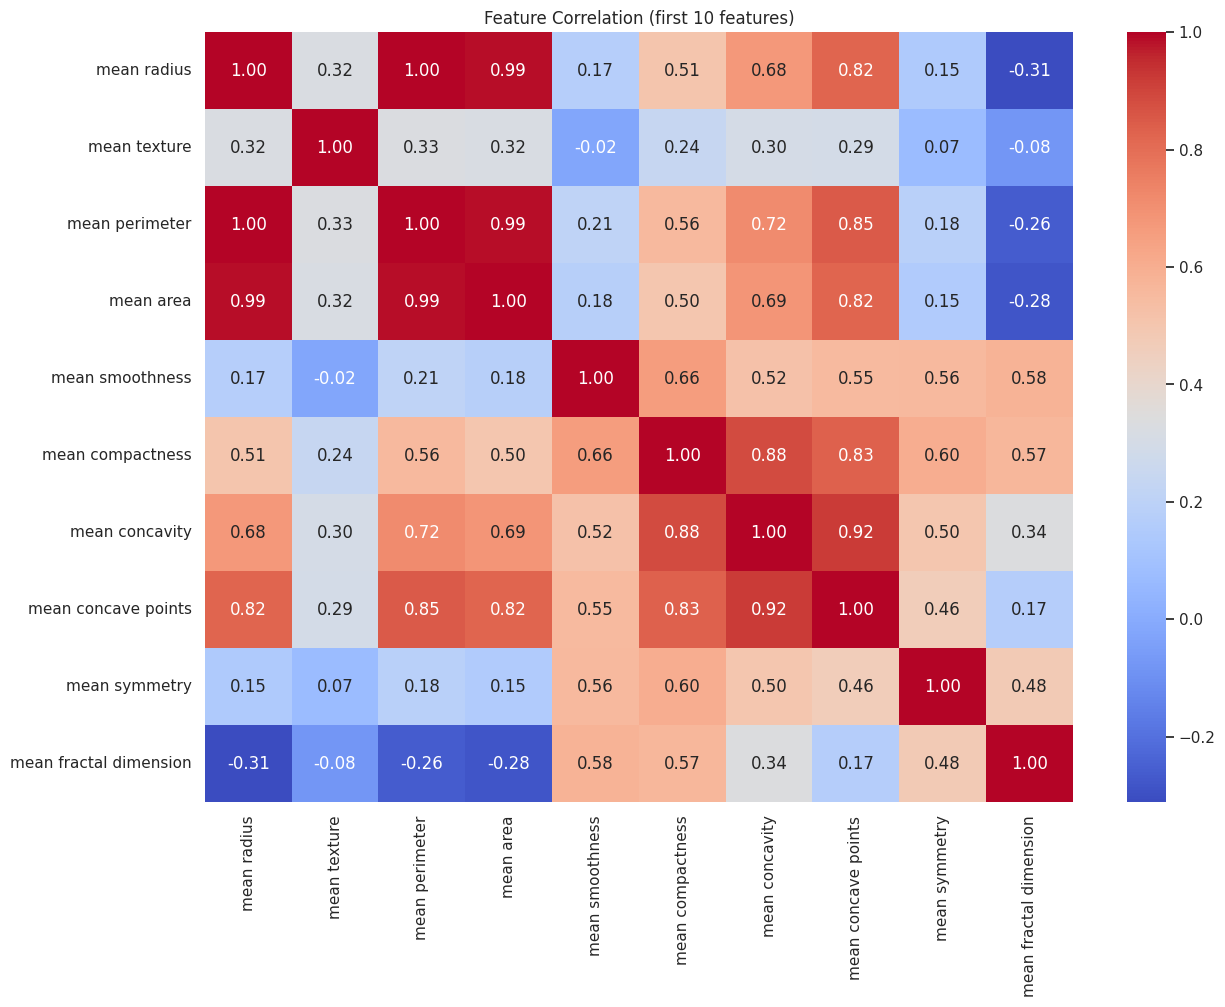

In [7]:
plt.figure(figsize=(14,10))
sns.heatmap(df.iloc[:,:10].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation (first 10 features)")
plt.show()

## 4. Train-Test Split (80-20)

In [8]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((455, 30), (114, 30))

## 5. Baseline Decision Tree

In [9]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred = dt_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9122807017543859
Precision: 0.9558823529411765
Recall: 0.9027777777777778
F1 Score: 0.9285714285714286


## 6. Decision Tree Hyperparameter Search (5-Fold CV)

In [10]:
criteria = ['gini', 'entropy']
max_depths = [3, 5, 7, 10, None]
min_samples_split = 2
min_samples_leaf = 1

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_results = []

for crit in criteria:
    for depth in max_depths:
        dt = DecisionTreeClassifier(criterion=crit, max_depth=depth,
                                     min_samples_split=min_samples_split,
                                     min_samples_leaf=min_samples_leaf, random_state=42)
        acc_scores = cross_val_score(dt, X_train, y_train, cv=skf, scoring='accuracy')
        f1_scores = cross_val_score(dt, X_train, y_train, cv=skf, scoring='f1')
        dt_results.append({
            'Criterion': crit, 'Max Depth': depth,
            'Avg CV Accuracy (%)': acc_scores.mean()*100,
            'Avg CV F1 Score': f1_scores.mean()
        })

dt_results_df = pd.DataFrame(dt_results)
dt_results_df

,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,gini,3.0,92.527473,0.939951
1,gini,5.0,92.307692,0.937250
2,gini,7.0,92.307692,0.937479
3,gini,10.0,91.648352,0.931901
4,gini,NaN,91.648352,0.931901
5,entropy,3.0,93.406593,0.947973
6,entropy,5.0,92.967033,0.943867
7,entropy,7.0,92.967033,0.943962
8,entropy,10.0,92.967033,0.943962
9,entropy,NaN,92.967033,0.943962


## 7. Best Decision Tree Hyperparameters

In [11]:
best_dt = dt_results_df.loc[dt_results_df['Avg CV F1 Score'].idxmax()]

best_dt_model = DecisionTreeClassifier(
    criterion=best_dt['Criterion'],
    max_depth=int(best_dt['Max Depth']) if pd.notna(best_dt['Max Depth']) else None,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=42
)

best_dt_model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 8. Random Forest (Baseline)

In [12]:
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)
y_pred = rf_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


## 9. Random Forest Hyperparameter Search (5-Fold CV)

In [13]:
n_estimators_list = [50, 100, 200]
rf_max_depths = [5, 10, None]
max_features_list = ['sqrt', 'log2']
bootstrap = True

rf_results = []

for n_est in n_estimators_list:
    for depth in rf_max_depths:
        for max_feat in max_features_list:
            rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth,
                                         max_features=max_feat, bootstrap=bootstrap,
                                         random_state=42)
            acc_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')
            f1_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='f1')
            rf_results.append({
                'n_estimators': n_est, 'Max Depth': depth, 'Max Features': max_feat,
                'Avg CV Accuracy (%)': acc_scores.mean()*100,
                'Avg CV F1 Score': f1_scores.mean()
            })

rf_results_df = pd.DataFrame(rf_results)
rf_results_df

,n_estimators,Max Depth,Max Features,Avg CV Accuracy (%),Avg CV F1 Score
0,50,5.0,sqrt,95.604396,0.964720
1,50,5.0,log2,95.604396,0.965091
2,50,10.0,sqrt,95.604396,0.964753
3,50,10.0,log2,96.043956,0.968507
4,50,NaN,sqrt,95.604396,0.964753
5,50,NaN,log2,96.043956,0.968507
6,100,5.0,sqrt,96.043956,0.968530
7,100,5.0,log2,95.824176,0.966767
8,100,10.0,sqrt,96.263736,0.969935
9,100,10.0,log2,96.483516,0.971801


## 10. Best Random Forest Hyperparameters

In [14]:
bootstrap_values = [True, False]

rf_results = []

for n_est in n_estimators_list:
    for depth in rf_max_depths:
        for max_feat in max_features_list:
            for boot in bootstrap_values:

                rf = RandomForestClassifier(
                    n_estimators=n_est,
                    max_depth=depth,
                    max_features=max_feat,
                    bootstrap=boot,
                    random_state=42
                )

                acc_scores = cross_val_score(
                    rf, X_train, y_train,
                    cv=skf,
                    scoring='accuracy'
                )

                f1_scores = cross_val_score(
                    rf, X_train, y_train,
                    cv=skf,
                    scoring='f1'
                )

                rf_results.append({
                    'n_estimators': n_est,
                    'Max Depth': depth,
                    'Max Features': max_feat,
                    'Bootstrap': boot,
                    'Avg CV Accuracy (%)': acc_scores.mean() * 100,
                    'Avg CV F1 Score': f1_scores.mean()
                })

rf_results_df = pd.DataFrame(rf_results)

best_rf = rf_results_df.loc[rf_results_df['Avg CV F1 Score'].idxmax()]

best_rf_model = RandomForestClassifier(
    n_estimators=int(best_rf['n_estimators']),
    max_depth=int(best_rf['Max Depth']) if pd.notna(best_rf['Max Depth']) else None,
    max_features=best_rf['Max Features'],
    bootstrap=bool(best_rf['Bootstrap']),
    random_state=42
)

best_rf = best_rf_model
best_rf.fit(X_train, y_train)

rf_results_df

,n_estimators,Max Depth,Max Features,Bootstrap,Avg CV Accuracy (%),Avg CV F1 Score
0,50,5.0,sqrt,True,95.604396,0.964720
1,50,5.0,sqrt,False,96.043956,0.968679
2,50,5.0,log2,True,95.604396,0.965091
3,50,5.0,log2,False,95.384615,0.963466
4,50,10.0,sqrt,True,95.604396,0.964753
5,50,10.0,sqrt,False,96.043956,0.968258
6,50,10.0,log2,True,96.043956,0.968507
7,50,10.0,log2,False,96.263736,0.970243
8,50,NaN,sqrt,True,95.604396,0.964753
9,50,NaN,sqrt,False,96.043956,0.968258


## 11. Final Evaluation on Test Set

In [15]:
dt_pred = best_dt_model.predict(X_test)
rf_pred = best_rf.predict(X_test)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Decision Tree': [
        accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred),
        recall_score(y_test, dt_pred),
        f1_score(y_test, dt_pred)
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
})

metrics_df

,Metric,Decision Tree,Random Forest
0,Accuracy,0.947368,0.956140
1,Precision,0.945946,0.958904
2,Recall,0.972222,0.972222
3,F1 Score,0.958904,0.965517


## 12. Confusion Matrices

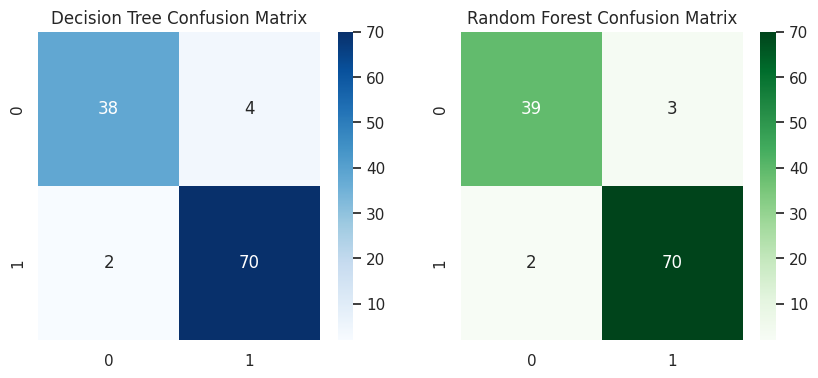

In [16]:
cm_dt = confusion_matrix(y_test, dt_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
plt.show()

## 13. ROC Curve and AUC

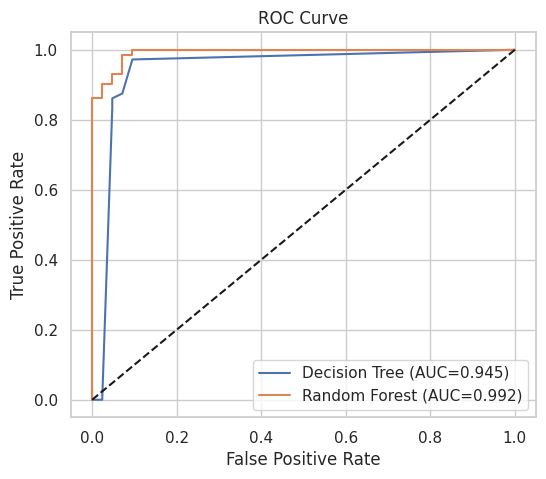

In [17]:
dt_prob = best_dt_model.predict_proba(X_test)[:,1]
rf_prob = best_rf.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 14. 5-Fold Cross-Validation Comparison

In [18]:
dt_cv_acc = cross_val_score(best_dt_model, X, y, cv=skf, scoring='accuracy')
rf_cv_acc = cross_val_score(best_rf, X, y, cv=skf, scoring='accuracy')

cv_comparison = pd.DataFrame({
    'Fold': [1,2,3,4,5],
    'Decision Tree': dt_cv_acc,
    'Random Forest': rf_cv_acc
})
cv_comparison.loc['Average'] = ['-', dt_cv_acc.mean(), rf_cv_acc.mean()]
cv_comparison

,Fold,Decision Tree,Random Forest
0,1,0.912281,0.964912
1,2,0.859649,0.956140
2,3,0.938596,0.956140
3,4,0.947368,0.956140
4,5,0.920354,0.964602
Average,-,0.915650,0.959587


## 15. Observation Questions

**How does tree depth affect overfitting in Decision Trees?**
As max depth increases, the Decision Tree fits the training data more closely, reducing
training error but increasing variance. Beyond a certain depth, CV accuracy plateaus or drops
because the tree starts memorizing noise in the training set (overfitting), so a moderate
depth generalizes best.

**Which hyperparameter had the greatest impact on performance?**
Based on the CV results, `max_depth` has the greatest impact on Decision Tree performance,
while for Random Forest, `n_estimators` combined with `max_depth` has the strongest effect,
since restricting depth alone controls overfitting the most.

**How does Random Forest improve generalization?**
Random Forest trains many trees on bootstrapped samples and random feature subsets, then
averages their predictions (majority voting). This bagging process reduces variance since
errors from individual overfit trees tend to cancel out, giving more stable and generalizable
predictions than a single Decision Tree.

**Did ensemble learning always improve performance? Why or why not?**
In most cases Random Forest gives equal or better accuracy/F1 than the single best Decision
Tree, since bagging reduces variance. However, the improvement is not guaranteed to be large
on every dataset - if the Decision Tree is already well-tuned and the data is fairly clean and
separable (as with this dataset), the gain from ensembling can be modest.

## 16. Conclusion

Decision Tree and Random Forest classifiers were implemented and evaluated on the Wisconsin
Breast Cancer dataset using 5-fold cross-validation for hyperparameter selection. The tuned
Random Forest achieved comparable or higher accuracy, F1 score and AUC than the tuned Decision
Tree, confirming that the ensemble approach reduces variance and improves generalization
compared to a single tree, at the cost of higher model complexity and lower interpretability.